# Classification Perfomance based on Explanations

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, abspath
from collections import Counter
import numpy as np
from os.path import join
sys.path.append("../..")


from config import DATA_DIR, ALL_GROUPS
from utils.classification_helpers import group_ihra_content, group_lexicon_content, map_lexicon_chapters_to_ihra_sections, flatten, count_items, compute_multilabel_prec_recall, plot_distribution_diff, plot_distribution_diff_pair

In [161]:
PROVIDER = "gpt"

In [162]:
bloomington = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_bloomington_label_1.feather"))
decoding = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_decoding_label_1.feather"))

In [163]:

column_name_renaming = {
    'classification_ihra_explanation_cleaned': 'IHRA_c',
    'explanation_ihra_explanation_cleaned': 'IHRA_e',
    'classification_tax': 'TAX_c',
    'explanation_tax': 'TAX_e',
    'classification_tax_ex': 'TAX_EX_c',
    'explanation_tax_ex': 'TAX_EX_e',

    'explanation_ihra_explanation_sections': 'IHRA_e_sections',
    'explanation_tax_chapters': 'TAX_e_chapters',
    'explanation_tax_chapters_no': 'TAX_e_chapters_no',
    'explanation_tax_ex_chapters': 'TAX_EX_e_chapters',
    'explanation_tax_ex_chapters_no': 'TAX_EX_e_chapters_no',
    'explanation_tax_sections': 'TAX_e_sections',
    'explanation_tax_ex_sections': 'TAX_EX_e_sections',
}
bloomington.rename(columns=column_name_renaming, inplace=True)
decoding.rename(columns=column_name_renaming, inplace=True)

REL_CLASS_COLS = column_name_renaming.values()

BLOOMINGTON_DATA_COLS = ['comment_cleaned', 'keyword', 'ihra_sections']
DECODING_DATA_COLS = ['comment_cleaned', 'comment_codes_all_list', 'comment_codes_all_chapters', 'comment_codes_all_sections']


# Bloomington

### IHRA

In [164]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [165]:
len(bloomington_ihra)

906

In [166]:
bloomington_ihra['overlap'] = bloomington_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_ihra['overlap'].mean()

np.float64(0.9293598233995585)

In [167]:
b_sections_count, b_sections_count_norm = count_items(bloomington["ihra_sections"])
sum(b_sections_count.values())/len(bloomington)

1.3003229278794401

In [169]:
b_ihra_sections_count, b_ihra_sections_count_norm = count_items(bloomington_ihra["ihra_sections"])

In [170]:
# total sum of annotator sections
sum(b_ihra_sections_count.values())

1207

In [172]:
bloomington_ihra["ihra_sections_cnt"] = bloomington_ihra["ihra_sections"].map(len)
bloomington_ihra["IHRA_e_sections_cnt"] = bloomington_ihra["IHRA_e_sections"].map(len)
bloomington_ihra[["ihra_sections_cnt", "IHRA_e_sections_cnt"]].describe()

,ihra_sections_cnt,IHRA_e_sections_cnt
count,906.000000,906.000000
mean,1.332230,1.412804
std,0.475939,0.531454
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,2.000000,3.000000


#### Group level

In [ ]:
bloomington_ihra['explanation_same_content_groups'] = bloomington_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
b_ihra_groups_count, b_ihra_groups_count_norm = count_items(bloomington_ihra["annotators_content_groups"], interpret_as_int=False)
b_ihra_e_groups_count, b_ihra_e_groups_count_norm = count_items(bloomington_ihra["explanation_content_groups"], interpret_as_int=False)
b_ihra_e_groups_same_count, b_ihra_e_groups_same_count_norm = count_items(bloomington_ihra["explanation_same_content_groups"], interpret_as_int=False)

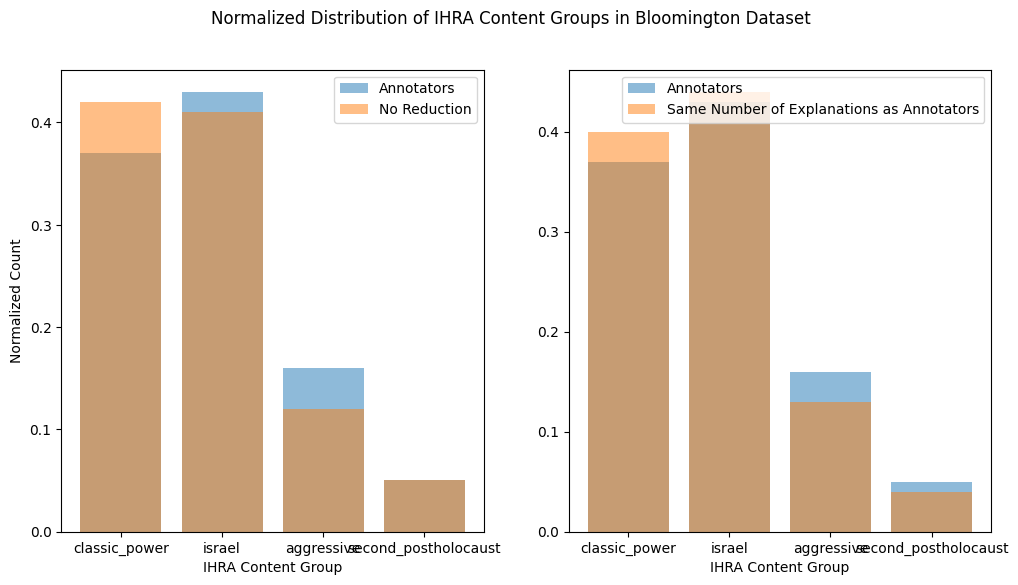

In [185]:
plot_distribution_diff_pair(
    b_ihra_groups_count_norm,
    b_ihra_e_groups_count_norm,
    b_ihra_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of IHRA Content Groups in Bloomington Dataset',
    'IHRA Content Group',
    normalized=True)

In [187]:
len(bloomington_ihra[bloomington_ihra["overlap"]==1])/len(bloomington_ihra)

0.9293598233995585

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [188]:
compute_multilabel_prec_recall(bloomington_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,174,135,87,0.500000,0.644444
3,classic_power,411,482,337,0.819951,0.699170
2,israel,478,461,432,0.903766,0.937093
1,second_postholocaust,57,57,25,0.438596,0.438596


### TAX

In [192]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax.head()

bloomington_tax['overlap'] = bloomington_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax['overlap'].mean()

np.float64(0.9288135593220339)

In [193]:
bloomington_tax["ihra_sections_cnt"] = bloomington_tax["ihra_sections"].map(len)
bloomington_tax["tax_e_chapters_cnt"] = bloomington_tax["TAX_e_chapters"].map(len)

In [194]:
b_tax_sections_count, b_tax_sections_count_norm = count_items(bloomington_tax["ihra_sections"])

In [195]:
sum(b_tax_sections_count.values())

1595

In [196]:
b_tax_e_chapters_count, b_tax_e_chapters_count_norm = count_items(bloomington_tax["TAX_e_chapters"])

In [197]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [198]:
bloomington_tax["TAX_e_chapters_max_2"] = bloomington_tax["TAX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax["TAX_e_chapters_max_2_cnt"] = bloomington_tax["TAX_e_chapters_max_2"].map(len)
bloomington_tax["TAX_e_chapters_same"] = bloomington_tax.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax["TAX_e_chapters_same_cnt"] = bloomington_tax["TAX_e_chapters_same"].map(len)
bloomington_tax[["ihra_sections_cnt", "tax_e_chapters_cnt", "TAX_e_chapters_max_2_cnt", "TAX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_e_chapters_cnt,TAX_e_chapters_max_2_cnt,TAX_e_chapters_same_cnt
count,1180.000000,1180.000000,1180.000000,1180.000000
mean,1.351695,3.135593,1.956780,1.344068
std,0.477702,1.224677,0.203439,0.475265
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,3.000000,2.000000,1.000000
75%,2.000000,4.000000,2.000000,2.000000
max,2.000000,10.000000,2.000000,2.000000


In [ ]:
bloomington_tax['explanation_same_content_groups'] = bloomington_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_groups_count, b_tax_groups_count_norm = count_items(bloomington_tax["annotators_content_groups"], interpret_as_int=False)
b_tax_e_groups_count, b_tax_e_groups_count_norm = count_items(bloomington_tax["explanation_content_groups"], interpret_as_int=False)
b_tax_e_groups_same_count, b_tax_e_groups_same_count_norm = count_items(bloomington_tax["explanation_same_content_groups"], interpret_as_int=False)

In [201]:
b_tax_groups_count

Counter({'israel': 701,
         'classic_power': 465,
         'aggressive': 195,
         'second_postholocaust': 69,
         None: 38})

In [202]:
b_tax_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

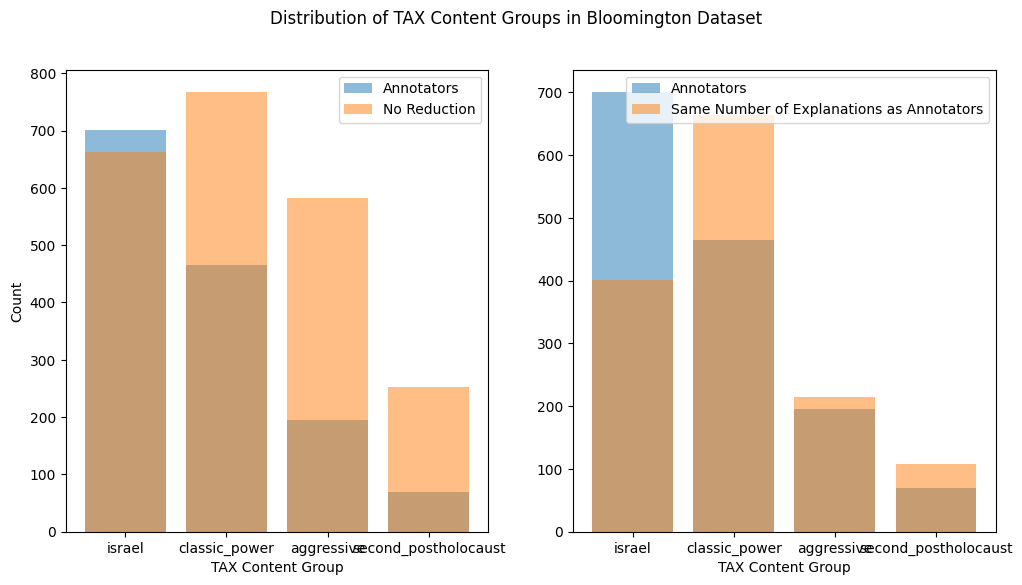

In [205]:
plot_distribution_diff_pair(
    b_tax_groups_count,
    b_tax_e_groups_count,
    b_tax_e_groups_same_count,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Distribution of TAX Content Groups in Bloomington Dataset',
    'TAX Content Group',
    normalized=False)

In [207]:
compute_multilabel_prec_recall(bloomington_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,195,582,168,0.861538,0.288660
3,classic_power,465,768,393,0.845161,0.511719
2,israel,701,662,637,0.908702,0.962236
1,second_postholocaust,69,253,52,0.753623,0.205534


### TAX EX

In [210]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex.head()

bloomington_tax_ex['overlap'] = bloomington_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax_ex['overlap'].mean()

np.float64(0.9207011686143572)

In [211]:
bloomington_tax_ex["ihra_sections_cnt"] = bloomington_tax_ex["ihra_sections"].map(len)
bloomington_tax_ex["tax_ex_e_chapters_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(len)

In [212]:
b_tax_ex_sections_count, b_tax_ex_sections_count_norm = count_items(bloomington_tax_ex["ihra_sections"])

In [214]:
b_tax_ex_e_chapters_count, b_tax_ex_e_chapters_count_norm = count_items(bloomington_tax_ex["TAX_EX_e_chapters"])

In [215]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [216]:
bloomington_tax_ex["TAX_EX_e_chapters_max_2"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax_ex["TAX_EX_e_chapters_max_2_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_max_2"].map(len)
bloomington_tax_ex["TAX_EX_e_chapters_same"] = bloomington_tax_ex.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_EX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax_ex["TAX_EX_e_chapters_same_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_same"].map(len)
bloomington_tax_ex[["ihra_sections_cnt", "tax_ex_e_chapters_cnt", "TAX_EX_e_chapters_max_2_cnt", "TAX_EX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_ex_e_chapters_cnt,TAX_EX_e_chapters_max_2_cnt,TAX_EX_e_chapters_same_cnt
count,1198.000000,1198.000000,1198.000000,1198.000000
mean,1.342237,2.813856,1.922371,1.321369
std,0.474657,1.084365,0.267699,0.467197
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,3.000000,2.000000,1.000000
75%,2.000000,4.000000,2.000000,2.000000
max,2.000000,8.000000,2.000000,2.000000


In [ ]:
bloomington_tax_ex['explanation_same_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_ex_groups_count, b_tax_ex_groups_count_norm = count_items(bloomington_tax_ex["annotators_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_count, b_tax_ex_e_groups_count_norm = count_items(bloomington_tax_ex["explanation_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_same_count, b_tax_ex_e_groups_same_count_norm = count_items(bloomington_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

In [220]:
b_tax_ex_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_ex_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

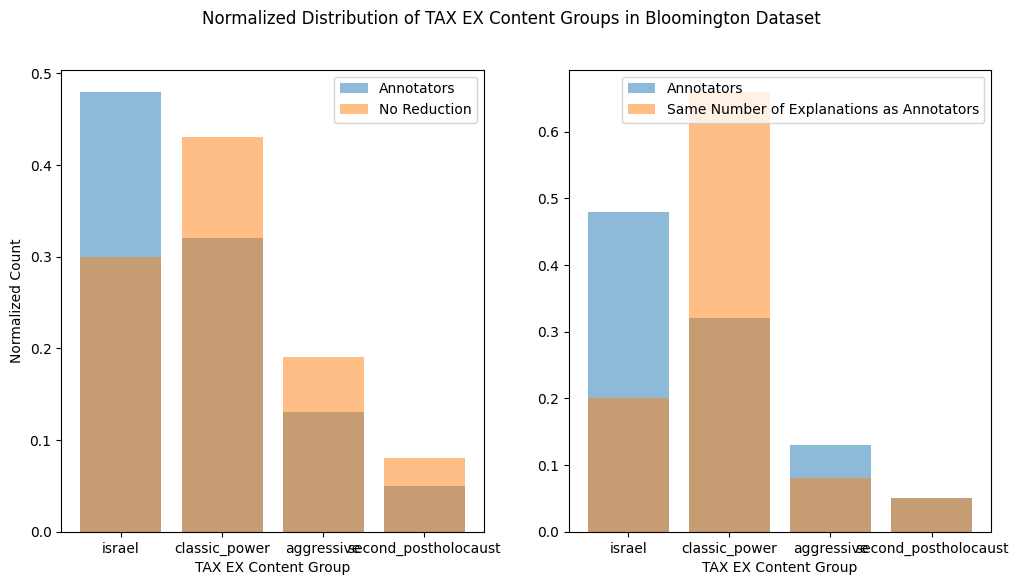

In [224]:
plot_distribution_diff_pair(
    b_tax_ex_groups_count_norm,
    b_tax_ex_e_groups_count_norm,
    b_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of TAX EX Content Groups in Bloomington Dataset',
    'TAX EX Content Group',
    normalized=True)

In [225]:
compute_multilabel_prec_recall(bloomington_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,190,418,145,0.763158,0.346890
3,classic_power,447,951,407,0.910515,0.427971
2,israel,740,677,658,0.889189,0.971935
1,second_postholocaust,66,184,42,0.636364,0.228261


# Decoding

In [228]:
d_chapters_count, d_chapters_count_norm = count_items(decoding["comment_codes_all_chapters"])
sum(d_chapters_count.values())/len(decoding)

1.4783338931810548

### IHRA

Can be compared on the level of groups only

In [230]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]

In [231]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra.tail()

decoding_ihra['overlap'] = decoding_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_ihra['overlap'].mean()

np.float64(0.8346456692913385)

In [232]:
decoding_ihra["lexicon_chapters_cnt"] = decoding_ihra["comment_codes_all_chapters"].map(len)
decoding_ihra["IHRA_e_sections_cnt"] = decoding_ihra["IHRA_e_sections"].map(len)

In [233]:
d_ihra_chapters_count, d_ihra_chapters_count_norm = count_items(decoding_ihra["comment_codes_all_chapters"])
#sum(d_ihra_chapters_count.values())

In [234]:
d_ihra_e_sections_count, d_ihra_e_sections_count_norm = count_items(decoding_ihra["IHRA_e_sections"])

In [235]:
decoding_ihra["IHRA_e_sections_max_2"] = decoding_ihra["IHRA_e_sections"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
decoding_ihra["IHRA_e_sections_max_2_cnt"] = decoding_ihra["IHRA_e_sections_max_2"].map(len)
decoding_ihra["IHRA_e_sections_same"] = decoding_ihra.apply(lambda x: reduce_to_same_number(x, to_reduce_col="IHRA_e_sections", reference_col="lexicon_chapters_cnt"), axis=1)
decoding_ihra["IHRA_e_sections_same_cnt"] = decoding_ihra["IHRA_e_sections_same"].map(len)
decoding_ihra[["lexicon_chapters_cnt", "IHRA_e_sections_cnt", "IHRA_e_sections_max_2_cnt", "IHRA_e_sections_same_cnt"]].describe()

,lexicon_chapters_cnt,IHRA_e_sections_cnt,IHRA_e_sections_max_2_cnt,IHRA_e_sections_same_cnt
count,635.000000,635.000000,635.000000,635.000000
mean,1.661417,1.429921,1.414173,1.192126
std,1.112167,0.526328,0.492967,0.477508
min,0.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,1.000000
max,8.000000,3.000000,2.000000,3.000000


In [ ]:
decoding_ihra['explanation_same_content_groups'] = decoding_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
d_ihra_groups_count, d_ihra_groups_count_norm = count_items(decoding_ihra["annotators_content_groups"], interpret_as_int=False)
d_ihra_e_groups_count, d_ihra_e_groups_count_norm = count_items(decoding_ihra["explanation_content_groups"], interpret_as_int=False)
d_ihra_e_groups_same_count, d_ihra_e_groups_same_count_norm = count_items(decoding_ihra["explanation_same_content_groups"], interpret_as_int=False)

In [242]:
d_ihra_e_groups_count = {key: value for key, value in d_ihra_e_groups_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_count_norm = {key: value for key, value in d_ihra_e_groups_count_norm.items() if key in ALL_GROUPS}

d_ihra_e_groups_same_count = {key: value for key, value in d_ihra_e_groups_same_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_same_count_norm = {key: value for key, value in d_ihra_e_groups_same_count_norm.items() if key in ALL_GROUPS}

In [245]:
compute_multilabel_prec_recall(decoding_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,45,83,29,0.644444,0.349398
3,classic_power,329,320,247,0.750760,0.771875
2,israel,338,321,267,0.789941,0.831776
1,second_postholocaust,106,104,36,0.339623,0.346154


### TAX

In [248]:
decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax.head()

decoding_tax['overlap'] = decoding_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax['overlap'].mean()

np.float64(0.9014778325123153)

In [249]:
decoding_tax["tax_chapters_cnt"] = decoding_tax["comment_codes_all_chapters"].map(len)
decoding_tax["tax_e_chapters_cnt"] = decoding_tax["TAX_e_chapters"].map(len)
decoding_tax[["tax_chapters_cnt", "tax_e_chapters_cnt"]].describe()

,tax_chapters_cnt,tax_e_chapters_cnt
count,1421.000000,1421.000000
mean,1.578466,3.073188
std,0.986708,1.230593
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,3.000000
75%,2.000000,4.000000
max,8.000000,10.000000


In [250]:
d_tax_chapters_count, d_tax_chapters_count_norm = count_items(decoding_tax["comment_codes_all_chapters"])
sum(d_tax_chapters_count.values())

2243

In [252]:
d_tax_e_chapters_count, d_tax_e_chapters_count_norm = count_items(decoding_tax["TAX_e_chapters"])
# sum(d_tax _e_chapters_count.values())

#### Group level

In [ ]:
decoding_tax['explanation_same_content_groups'] = decoding_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_groups_count, d_tax_groups_count_norm = count_items(decoding_tax["annotators_content_groups"], interpret_as_int=False)
d_tax_e_groups_count, d_tax_e_groups_count_norm = count_items(decoding_tax["explanation_content_groups"], interpret_as_int=False)
d_tax_e_groups_same_count, d_tax_e_groups_same_count_norm = count_items(decoding_tax["explanation_same_content_groups"], interpret_as_int=False)

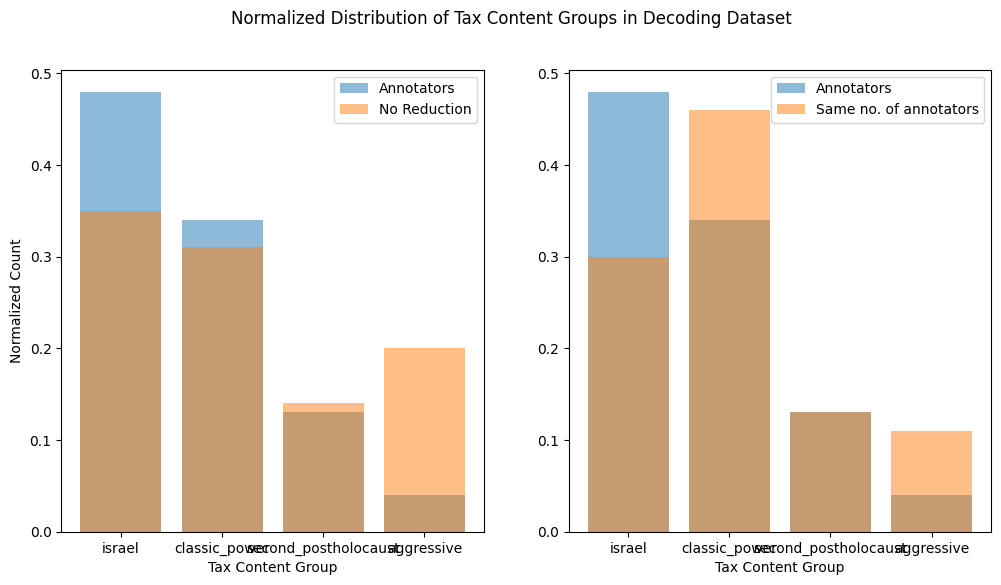

In [277]:
plot_distribution_diff_pair(
    d_tax_groups_count_norm,
    d_tax_e_groups_count_norm,
    d_tax_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Content Groups in Decoding Dataset',
    'Tax Content Group',
    normalized=True)

In [278]:
compute_multilabel_prec_recall(decoding_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,76,543,65,0.855263,0.119705
3,classic_power,613,849,429,0.699837,0.505300
2,israel,874,970,808,0.924485,0.832990
1,second_postholocaust,240,388,176,0.733333,0.453608


### TAX_EX

In [282]:
decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex.head()

decoding_tax_ex['overlap'] = decoding_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax_ex['overlap'].mean()

np.float64(0.9285714285714286)

In [283]:
decoding_tax_ex["tax_ex_chapters_cnt"] = decoding_tax_ex["comment_codes_all_chapters"].map(len)
decoding_tax_ex["tax_ex_e_chapters_cnt"] = decoding_tax_ex["TAX_EX_e_chapters"].map(len)
decoding_tax_ex[["tax_ex_chapters_cnt", "tax_ex_e_chapters_cnt"]].describe()

,tax_ex_chapters_cnt,tax_ex_e_chapters_cnt
count,1638.000000,1638.00000
mean,1.608059,2.73138
std,0.993680,1.11682
min,0.000000,1.00000
25%,1.000000,2.00000
50%,1.000000,3.00000
75%,2.000000,3.00000
max,8.000000,9.00000


#### Group level

In [ ]:
decoding_tax_ex['explanation_same_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_ex_groups_count, d_tax_ex_groups_count_norm = count_items(decoding_tax_ex["annotators_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_count, d_tax_ex_e_groups_count_norm = count_items(decoding_tax_ex["explanation_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_same_count, d_tax_ex_e_groups_same_count_norm = count_items(decoding_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

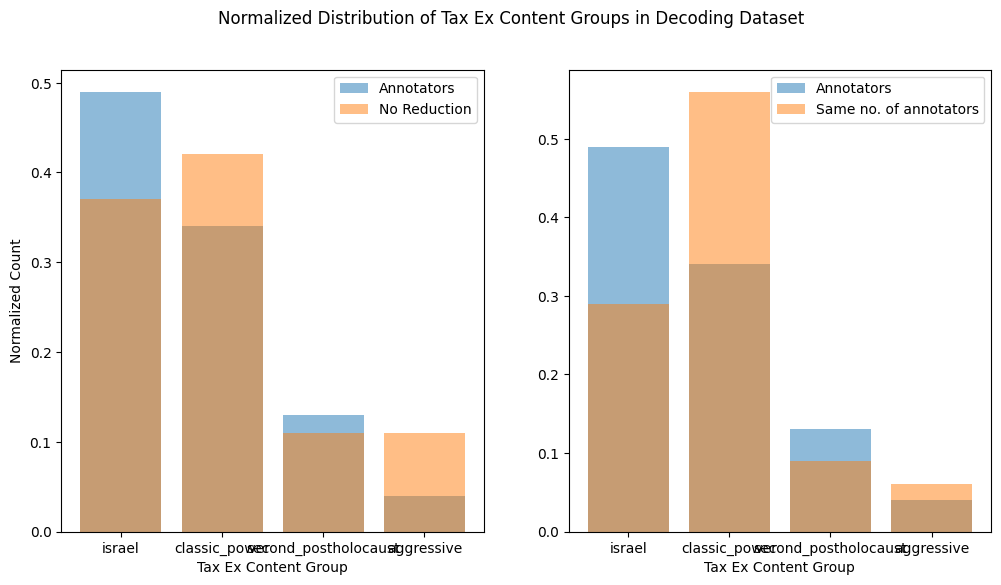

In [311]:
plot_distribution_diff_pair(
    d_tax_ex_groups_count_norm,
    d_tax_ex_e_groups_count_norm,
    d_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Ex Content Groups in Decoding Dataset',
    'Tax Ex Content Group',
    normalized=True)

In [312]:
compute_multilabel_prec_recall(decoding_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,86,305,68,0.790698,0.222951
3,classic_power,710,1205,605,0.852113,0.502075
2,israel,1025,1058,934,0.911220,0.882798
1,second_postholocaust,281,320,202,0.718861,0.631250


# DATASET UNION

## IHRA

In [ ]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra["dataset_id"] = "b"
bloomington_ihra = bloomington_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra["dataset_id"] = "d"
decoding_ihra = decoding_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_ihra = pd.concat([bloomington_ihra, decoding_ihra], ignore_index=True)

In [317]:
df_union_ihra['overlap'] = df_union_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_ihra['overlap'].mean()



np.float64(0.890330953926022)

In [318]:
df_union_ihra["annotator_content_cnt"] = df_union_ihra["annotators_content_groups"].map(len)
df_union_ihra["model_content_count"] = df_union_ihra["explanation_content_groups"].map(len)
df_union_ihra[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,1541.000000,1541.000000
mean,1.257625,1.273848
std,0.498519,0.456153
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,3.000000,3.000000


#### Group level

In [319]:
u_ihra_groups_count, u_ihra_groups_count_norm = count_items(df_union_ihra["annotators_content_groups"], interpret_as_int=False)
u_ihra_e_groups_count, u_ihra_e_groups_count_norm = count_items(df_union_ihra["explanation_content_groups"], interpret_as_int=False)

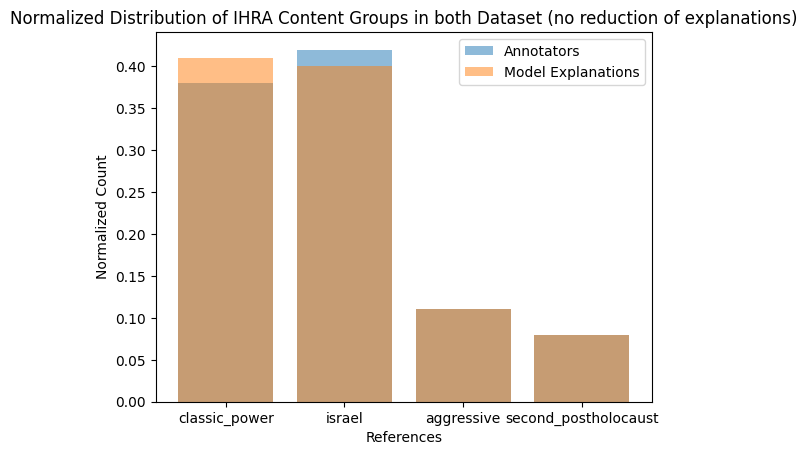

In [320]:
plot_distribution_diff(
    u_ihra_groups_count_norm, 
    u_ihra_e_groups_count_norm, 
    'Normalized Distribution of IHRA Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [321]:
compute_multilabel_prec_recall(df_union_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,219,218,116,0.529680,0.532110
3,classic_power,740,802,584,0.789189,0.728180
2,israel,816,782,699,0.856618,0.893862
1,second_postholocaust,163,161,61,0.374233,0.378882


## TAX

In [322]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e', 'TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax["dataset_id"] = "b"
bloomington_tax = bloomington_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax["dataset_id"] = "d"
decoding_tax = decoding_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax = pd.concat([bloomington_tax, decoding_tax], ignore_index=True)
df_union_tax.sample(2)

,comment_cleaned,annotators_content_groups,TAX_e,explanation_content_groups,dataset_id
1272,You voted for this government and your governm...,[israel],The post addresses an Israeli/Jewish addressee...,"[classic_power, israel, second_postholocaust]",d
2498,"nobody likes the jews in Europe, not only Germ...",[second_postholocaust],The text makes a sweeping negative generalizat...,[classic_power],d


In [324]:
bloomington_tax['annotators_content_groups'].value_counts()

annotators_content_groups
[israel]                                 483
[classic_power]                          317
[classic_power, israel]                  116
[aggressive]                              95
[israel, aggressive]                      73
[second_postholocaust, israel]            29
[second_postholocaust]                    27
[classic_power, aggressive]               23
[classic_power, second_postholocaust]      9
[second_postholocaust, aggressive]         4
[]                                         4
Name: count, dtype: int64

In [325]:
df_union_tax['overlap'] = df_union_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax['overlap'].mean()

np.float64(0.9138792772010765)

In [326]:
df_union_tax["annotator_content_cnt"] = df_union_tax["annotators_content_groups"].map(len)
df_union_tax["model_content_count"] = df_union_tax["explanation_content_groups"].map(len)
df_union_tax[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2601.000000,2601.000000
mean,1.242983,1.928105
std,0.490853,0.717784
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [327]:
u_tax_groups_count, u_tax_groups_count_norm = count_items(df_union_tax["annotators_content_groups"], interpret_as_int=False)
u_tax_e_groups_count, u_tax_e_groups_count_norm = count_items(df_union_tax["explanation_content_groups"], interpret_as_int=False)
print(u_tax_groups_count)
print(u_tax_e_groups_count)

Counter({'israel': 1575, 'classic_power': 1078, 'second_postholocaust': 309, 'aggressive': 271})
Counter({'israel': 1632, 'classic_power': 1617, 'aggressive': 1125, 'second_postholocaust': 641})


In [328]:
# get all unique items across all lists
all_items = set(item for sublist in df_union_tax["annotators_content_groups"] if isinstance(sublist, list) for item in sublist)
print(all_items)

{'classic_power', 'aggressive', 'second_postholocaust', 'israel'}


In [329]:
for item in all_items:
    result = group_ihra_content(item)  # or group_lexicon_content, whichever is relevant here
    if result is None:
        print(f"Input '{item}' maps to None")

Input 'classic_power' maps to None
Input 'aggressive' maps to None
Input 'second_postholocaust' maps to None
Input 'israel' maps to None


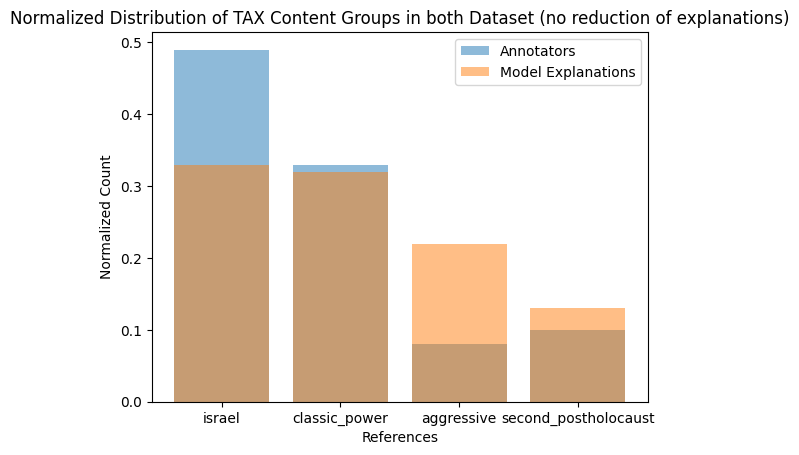

In [330]:
plot_distribution_diff(
    u_tax_groups_count_norm, 
    u_tax_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [331]:
compute_multilabel_prec_recall(df_union_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,271,1125,233,0.859779,0.207111
3,classic_power,1078,1617,822,0.762523,0.508349
2,israel,1575,1632,1445,0.917460,0.885417
1,second_postholocaust,309,641,228,0.737864,0.355694


## TAX_EX

In [332]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex["dataset_id"] = "b"
bloomington_tax_ex = bloomington_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex["dataset_id"] = "d"
decoding_tax_ex = decoding_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax_ex = pd.concat([bloomington_tax_ex, decoding_tax_ex], ignore_index=True)
df_union_tax_ex.sample(2)

,comment_cleaned,annotators_content_groups,TAX_EX_e,explanation_content_groups,dataset_id
489,If #Germany really supports Israel then they s...,[second_postholocaust],The post is antisemitic because it invokes the...,[second_postholocaust],b
1001,only terrorists are the zionazis israel and it...,[israel],The post uses a Nazi analogy against Israel ('...,"[classic_power, aggressive, israel]",b


In [333]:
df_union_tax_ex['overlap'] = df_union_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax_ex['overlap'].mean()

np.float64(0.92524682651622)

In [334]:
df_union_tax_ex["annotator_content_cnt"] = df_union_tax_ex["annotators_content_groups"].map(len)
df_union_tax_ex["model_content_count"] = df_union_tax_ex["explanation_content_groups"].map(len)
df_union_tax_ex[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2836.000000,2836.000000
mean,1.250000,1.804654
std,0.496105,0.653785
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [335]:
u_tax_ex_groups_count, u_tax_ex_groups_count_norm = count_items(df_union_tax_ex["annotators_content_groups"], interpret_as_int=False)
u_tax_ex_e_groups_count, u_tax_ex_e_groups_count_norm = count_items(df_union_tax_ex["explanation_content_groups"], interpret_as_int=False)
print(u_tax_ex_groups_count)

Counter({'israel': 1765, 'classic_power': 1157, 'second_postholocaust': 347, 'aggressive': 276})


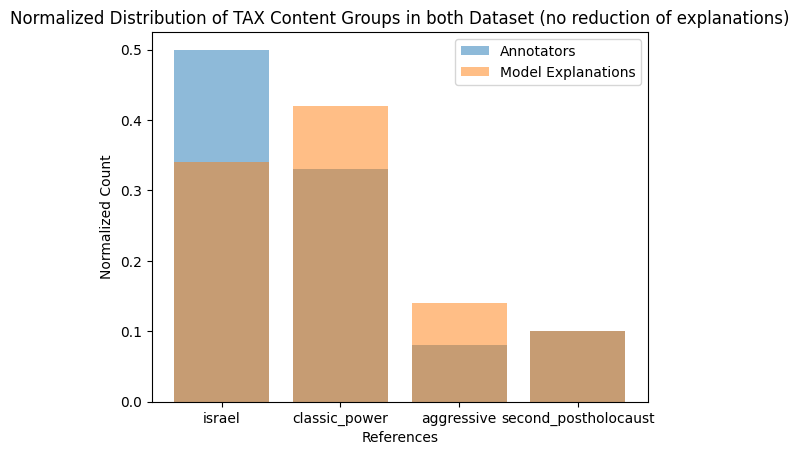

In [336]:
plot_distribution_diff(
    u_tax_ex_groups_count_norm, 
    u_tax_ex_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [337]:
compute_multilabel_prec_recall(df_union_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,276,723,213,0.771739,0.294606
3,classic_power,1157,2156,1012,0.874676,0.469388
2,israel,1765,1735,1592,0.901983,0.917579
1,second_postholocaust,347,504,244,0.703170,0.484127
